# Aula 8 · Parte 2 — Notebook 1: Holdout × validação cruzada

**Aprendizado de Máquina (PEPAPRM)** · IFSP Câmpus Presidente Epitácio

Objetivo: entender por que **uma única divisão treino/teste é uma estimativa instável**, como a **validação cruzada k-fold** resolve isso e como **escolher hiperparâmetros sem tocar no teste**.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, KFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
SEMENTE = 42
pd.set_option("display.width", 100)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from matplotlib.patches import Rectangle

In [2]:
def gerar_dados_emprestimo(n=450, semente=42):
    """Mesmo dataset das aulas de preparacao de dados: solicitacoes de
    emprestimo, com valores ausentes, uma coluna categorica e outliers."""
    rng = np.random.default_rng(semente)

    idade = rng.normal(38, 12, n).clip(18, 75).round().astype(float)
    score_credito = rng.normal(650, 80, n).clip(300, 850).round().astype(float)
    tempo_emprego = rng.normal(7, 5, n).clip(0, 35).round().astype(float)

    renda = rng.lognormal(mean=8.15, sigma=0.45, size=n)
    idx_outlier = rng.choice(n, size=5, replace=False)
    renda[idx_outlier] *= rng.uniform(6, 10, size=5)
    renda = renda.round(2)

    cidades = np.array(["SP", "RJ", "MG", "Outra"])
    cidade = rng.choice(cidades, size=n, p=[0.42, 0.23, 0.15, 0.20])

    renda_c = np.clip(renda, None, np.percentile(renda, 95))
    z = (
        0.05 * (score_credito - 650)
        + 0.0008 * (renda_c - renda_c.mean())
        + 0.12 * (tempo_emprego - 7)
        + rng.normal(0, 0.35, n)
    )
    prob_aprovado = 1 / (1 + np.exp(-z))
    aprovado = (rng.uniform(0, 1, n) < prob_aprovado).astype(int)

    df = pd.DataFrame({
        "idade": idade,
        "renda": renda,
        "tempo_emprego": tempo_emprego,
        "score_credito": score_credito,
        "cidade": cidade,
        "aprovado": aprovado,
    })

    mask_idade = rng.uniform(0, 1, n) < 0.08
    mask_renda = rng.uniform(0, 1, n) < 0.10
    mask_cidade = rng.uniform(0, 1, n) < 0.06
    df.loc[mask_idade, "idade"] = np.nan
    df.loc[mask_renda, "renda"] = np.nan
    df.loc[mask_cidade, "cidade"] = None
    return df


COL_NUM = ["idade", "renda", "tempo_emprego", "score_credito"]
COL_CAT = ["cidade"]


def montar_preprocessador():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("esc", StandardScaler())]), COL_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), COL_CAT),
    ])


def com_prep(modelo):
    return Pipeline([("prep", montar_preprocessador()), ("modelo", modelo)])



df = gerar_dados_emprestimo(n=450, semente=SEMENTE)
X = df.drop(columns="aprovado")
y = df["aprovado"]
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

## 1. Holdout: uma única divisão é instável

Mesmo modelo (regressão logística), mesmos dados — repetido em **200 divisões** treino/teste diferentes.

média = 0.849 | desvio = 0.030 | mínimo = 0.741 | máximo = 0.911


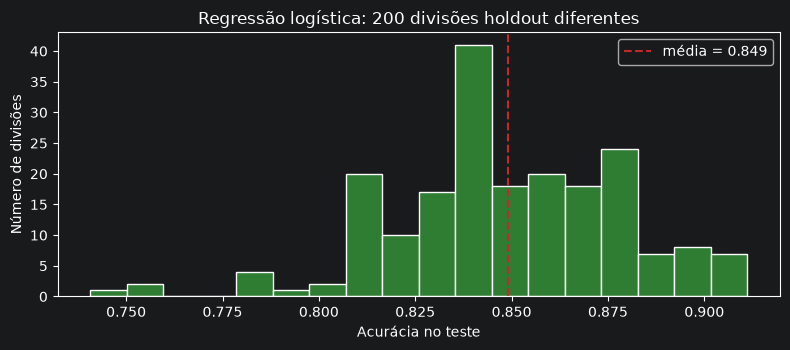

In [3]:
acuracias = []
for semente in range(200):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=semente, stratify=y)
    acuracias.append(com_prep(LogisticRegression(max_iter=1000)).fit(X_tr, y_tr).score(X_te, y_te))
acuracias = np.array(acuracias)
print(f"média = {acuracias.mean():.3f} | desvio = {acuracias.std():.3f} | "
      f"mínimo = {acuracias.min():.3f} | máximo = {acuracias.max():.3f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(acuracias, bins=18, color="#2e7d32", edgecolor="white")
ax.axvline(acuracias.mean(), color="#c62828", linestyle="--", label=f"média = {acuracias.mean():.3f}")
ax.set_xlabel("Acurácia no teste"); ax.set_ylabel("Número de divisões")
ax.set_title("Regressão logística: 200 divisões holdout diferentes")
ax.legend(); plt.tight_layout(); plt.show()

Quem fizesse uma única divisão poderia reportar qualquer valor entre o mínimo e o máximo — nenhum deles seria "errado". O holdout é simples e rápido, mas **não mostra a incerteza** da estimativa.

## 2. Validação cruzada k-fold

Cada exemplo aparece **uma vez** na validação e **k−1 vezes** no treino; o resultado é a **média** dos k desempenhos.

In [4]:
exemplos = np.arange(10)
for i, (idx_tr, idx_val) in enumerate(KFold(n_splits=5).split(exemplos), start=1):
    print(f"dobra {i}: validação = {idx_val}   treino = {idx_tr}")

dobra 1: validação = [0 1]   treino = [2 3 4 5 6 7 8 9]
dobra 2: validação = [2 3]   treino = [0 1 4 5 6 7 8 9]
dobra 3: validação = [4 5]   treino = [0 1 2 3 6 7 8 9]
dobra 4: validação = [6 7]   treino = [0 1 2 3 4 5 8 9]
dobra 5: validação = [8 9]   treino = [0 1 2 3 4 5 6 7]


Proporção de aprovados em cada dobra (StratifiedKFold):
  dobra 1: 90 exemplos | aprovados = 0.478
  dobra 2: 90 exemplos | aprovados = 0.478
  dobra 3: 90 exemplos | aprovados = 0.478
  dobra 4: 90 exemplos | aprovados = 0.478
  dobra 5: 90 exemplos | aprovados = 0.489
  proporção geral = 0.480


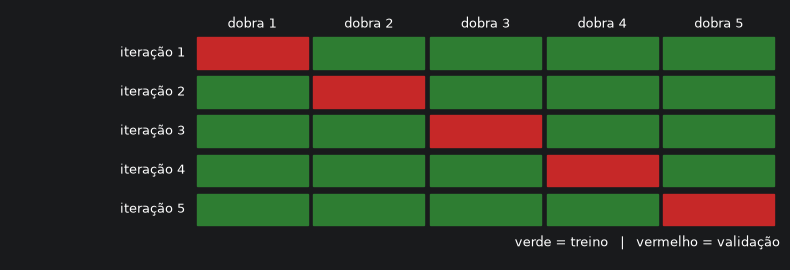

In [5]:
print("Proporção de aprovados em cada dobra (StratifiedKFold):")
for i, (idx_tr, idx_val) in enumerate(validacao.split(X, y), start=1):
    print(f"  dobra {i}: {len(idx_val)} exemplos | aprovados = {y.iloc[idx_val].mean():.3f}")
print(f"  proporção geral = {y.mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 2.8))
for i in range(5):
    for j in range(5):
        ax.add_patch(Rectangle((j, 4 - i), 0.95, 0.8, color="#c62828" if i == j else "#2e7d32"))
    ax.text(-0.1, 4 - i + 0.4, f"iteração {i + 1}", ha="right", va="center", fontsize=9)
for j in range(5):
    ax.text(j + 0.475, 5.05, f"dobra {j + 1}", ha="center", fontsize=9)
ax.set_xlim(-1.6, 5); ax.set_ylim(-0.9, 5.5); ax.axis("off")
ax.text(5, -0.55, "verde = treino   |   vermelho = validação", ha="right", fontsize=9)
plt.tight_layout(); plt.show()

**Estratificado** significa que cada dobra preserva a proporção de cada classe (importante quando uma classe é rara). `shuffle=True` embaralha antes de dividir, para que a ordem das linhas do arquivo não vire viés.

## 3. Comparando modelos com as mesmas dobras

O **mesmo** objeto `validacao` é usado por todos os modelos — comparação justa. Olhe a média **e** o desvio.

In [6]:
modelos = {
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Árvore (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=SEMENTE),
    "Naive Bayes": GaussianNB(),
    "SVM (rbf)": SVC(kernel="rbf", random_state=SEMENTE),
}
linhas = []
for nome, modelo in modelos.items():
    notas = cross_val_score(com_prep(modelo), X, y, cv=validacao)
    linhas.append((nome, notas.mean(), notas.std(), notas.min(), notas.max()))
pd.DataFrame(linhas, columns=["modelo", "média", "desvio", "mínimo", "máximo"]).set_index("modelo").round(3).sort_values("média", ascending=False)

,média,desvio,mínimo,máximo
modelo,,,,
SVM (rbf),0.860,0.038,0.800,0.900
Regressão Logística,0.856,0.045,0.778,0.900
Naive Bayes,0.820,0.046,0.756,0.878
Árvore (max_depth=4),0.807,0.038,0.733,0.844
k-NN (k=5),0.798,0.035,0.756,0.856


As médias de SVM (0,860) e regressão logística (0,856) diferem por muito menos que o desvio entre as dobras: na prática, estão **empatados**. Já SVM × k-NN (0,798) tem diferença de ~0,06, um sinal bem mais forte. **Regra:** se a diferença entre as médias é menor que a variação entre as dobras, não declare vencedor.

## 4. Escolher hiperparâmetros sem tocar no teste

Três papéis para os dados: **treino** (ajusta o modelo), **validação** (aqui, as dobras internas do `GridSearchCV` — escolhe hiperparâmetros) e **teste** (guardado até o fim, usado **uma vez**).

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEMENTE, stratify=y)
busca = GridSearchCV(com_prep(KNeighborsClassifier()),
                     param_grid={"modelo__n_neighbors": [1, 3, 5, 9, 15, 25, 45]},
                     cv=validacao)
busca.fit(X_tr, y_tr)

res = pd.DataFrame(busca.cv_results_)[["param_modelo__n_neighbors", "mean_test_score", "std_test_score"]]
res.columns = ["k", "média_cv", "desvio_cv"]
display(res.round(3))
print(f"Melhor k pela validação cruzada: {busca.best_params_['modelo__n_neighbors']}")
print(f"Acurácia média na validação cruzada: {busca.best_score_:.3f}")
print(f"Acurácia no TESTE (usado uma única vez): {busca.score(X_te, y_te):.3f}")

,k,média_cv,desvio_cv
0,1,0.694,0.048
1,3,0.754,0.061
2,5,0.775,0.048
3,9,0.801,0.053
4,15,0.825,0.052
5,25,0.846,0.033
6,45,0.834,0.029


Melhor k pela validação cruzada: 25
Acurácia média na validação cruzada: 0.846
Acurácia no TESTE (usado uma única vez): 0.867


Se você olha o teste para escolher `k` e depois reporta esse mesmo teste, a nota fica otimista — o teste deixou de ser "dado nunca visto".

### Para praticar
1. Troque `StratifiedKFold(5)` por `StratifiedKFold(10)` e veja o que muda na média e no desvio.
2. Rode o bloco 1 com `SVC` no lugar da regressão logística. A dispersão do holdout é parecida?